### Plaque Geometry Features

This module extends plaque distance features by computing geometric characteristics of each plaque (area, perimeter, major/minor axes, orientation) and associating them with cells based on their nearest plaque relationship.

#### Feature Computation

For each plaque polygon, we compute five geometric features:

1. **Area** (`plaque_area`): Total area enclosed by the plaque boundary (µm²)
2. **Perimeter** (`plaque_perimeter`): Total length of the plaque boundary (µm)
3. **Major Axis** (`plaque_major_axis_length`): Length of the longest edge of the minimum rotated rectangle (µm)
4. **Minor Axis** (`plaque_minor_axis_length`): Length of the shortest edge of the minimum rotated rectangle (µm)
5. **Orientation** (`plaque_orientation`): Angle of the major axis relative to horizontal (0-180°)



In [1]:
from src.scripts.analysis.spatial_features import add_plaque_geometry_features
combined_df_normalized_with_geometry = add_plaque_geometry_features(
    combined_df_normalized_full,
    plaques_poly,
    nearest_plaque_id_col="nearest_plaque_id"
)


ImportError: DLL load failed while importing _path: Le module spécifié est introuvable.

In [140]:
# Verify the new columns were added
print("\nNew columns added")
geometry_cols = [
    "nearest_plaque_area",
    "nearest_plaque_perimeter", 
    "nearest_plaque_major_axis",
    "nearest_plaque_minor_axis",
    "nearest_plaque_orientation"
]

# Display summary statistics
print("\n" + "="*80)
print("Summary statistics of plaque geometry features:")
print("="*80)
if geometry_cols:
    print(combined_df_normalized_with_geometry[geometry_cols].describe())
else:
    print("No geometry columns found in dataframe!")

# Check how many cells have valid geometry features
if "nearest_plaque_perimeter" in combined_df_with_geometry.columns:
    n_valid = combined_df_normalized_with_geometry["nearest_plaque_perimeter"].notna().sum()
    n_total = len(combined_df_normalized_with_geometry)
    print(f"\nCells with valid geometry features: {n_valid}/{n_total} ({100*n_valid/n_total:.1f}%)")
else:
    print("\n⚠️ Warning: nearest_plaque_perimeter column not found, skipping validation check")



New columns added

Summary statistics of plaque geometry features:
       nearest_plaque_area  nearest_plaque_perimeter  \
count         53895.000000              53895.000000   
mean            266.396974                 40.243726   
std            1678.235400                 70.533455   
min               6.654455                  9.485254   
25%              16.529213                 15.923917   
50%              47.475608                 26.369230   
75%             130.222927                 43.529781   
max           25837.231287                964.255037   

       nearest_plaque_major_axis  nearest_plaque_minor_axis  \
count               53895.000000               53895.000000   
mean                   14.647063                  14.647063   
std                    31.892705                  31.892705   
min                     2.924767                   2.924767   
25%                     5.754503                   5.754503   
50%                     9.295210                 

In [158]:
# Display sample rows
print("\n" + "="*80)
print("Sample of cells with geometry features:")
print("="*80)
# Only use columns that actually exist
display_cols = ["nearest_plaque_id"] + geometry_cols
if "nearest_plaque_id" in combined_df_normalized_with_geometry.columns:
    print(combined_df_normalized_with_geometry[display_cols].head(5))
else:
    print(combined_df_normalized_with_geometry[geometry_cols].head(5))


Sample of cells with geometry features:
   nearest_plaque_id  nearest_plaque_area  nearest_plaque_perimeter  \
0                 18            12.198375                 12.851615   
1                 19            16.476565                 15.049422   
2                 19            16.476565                 15.049422   
3                 18            12.198375                 12.851615   
4                 21           204.299936                 55.203979   

   nearest_plaque_major_axis  nearest_plaque_minor_axis  \
0                   3.900311                   3.900311   
1                   4.550028                   4.550028   
2                   4.550028                   4.550028   
3                   3.900311                   3.900311   
4                  17.191171                  17.191171   

   nearest_plaque_orientation  
0                   89.798521  
1                  179.823706  
2                  179.823706  
3                   89.798521  
4                

In [143]:
combined_df_normalized_full = combined_df_normalized_with_geometry.copy()

### Multi-Plaque Proximity Features:

Multi-plaque proximity features capture how "crowded with plaques" the local spatial environment around each cell is. While the nearest-plaque distance (`distance_to_plaque`) measures proximity to a single plaque, multi-plaque proximity features quantify the density of plaques within a local neighborhood, providing complementary spatial context that may better explain gene expression patterns and cellular responses.

For each cell with centroid coordinates $(x_i, y_i)$, we compute:


1. **Spatial Index Construction**: Build a **KDTree** (k-dimensional tree) on the plaque centroids using `scipy.spatial.KDTree`. 

2. **Radius Query**: For each cell $i$:
   - Query the KDTree to find all plaques within Euclidean distance $R$ (default: 30 µm):
     $$
     \mathcal{P}_i(R) = \{j : \|(x_i, y_i) - (c_{j,x}, c_{j,y})\|_2 \leq R\}
     $$
   - Compute two features:
     - **Count**: $n_i(R) = |\mathcal{P}_i(R)|$ (number of plaques within radius $R$)
     - **Mean Distance**: 
       $$
       \bar{d}_i(R) = \begin{cases}
       \frac{1}{|\mathcal{P}_i(R)|} \sum_{j \in \mathcal{P}_i(R)} \|(x_i, y_i) - (c_{j,x}, c_{j,y})\|_2 & \text{if } |\mathcal{P}_i(R)| > 0 \\
       \text{NaN} & \text{if } |\mathcal{P}_i(R)| = 0
       \end{cases}
       $$

3. **Output**: Add columns to the cell dataframe:
   - `n_plaques_within_Rum` (e.g., `n_plaques_within_30um`)
   - `mean_dist_to_plaques_within_Rum` (e.g., `mean_dist_to_plaques_within_30um`)

- All coordinates must be in the same units (microns)

**Threshold Selection**: The default radius $R = 30$ µm is chosen based on:

- Empirical observation: aligns with distance bins used in RQ1–RQ3 analyses
- Alternative: Use `suggest_radius_threshold()` to set $R$ based on the median distance to nearest plaque across all cells

## Diagnostic Analysis

### Threshold Validation

To determine if the chosen radius $R$ is informative, we provide a diagnostic plotting function that visualizes:

1. **Histogram**: Distribution of `n_plaques_within_R` across all cells
   - If almost all cells have $n_i(R) = 0$: radius may be too small
   - If almost all cells have $n_i(R) > 0$: radius may be too large
   - Ideal: mixed distribution with meaningful variation

2. **Cumulative Distribution Function (CDF)**: Shows the proportion of cells with $\leq k$ plaques within radius $R$

3. **Summary Statistics**: Mean, median, and percentage of cells with zero plaques

**Interpretation Guidelines**:
- **Good threshold**: Distribution shows variation (e.g., 30–70% of cells see 0 plaques, remainder see 1–5+)
- **Too small**: >90% of cells have 0 plaques → increase $R$
- **Too large**: <10% of cells have 0 plaques → decrease $R$

### Alternative Threshold Selection

The `suggest_radius_threshold()` function computes:
$$
R_{\text{suggested}} = \text{Percentile}_{p}(\{d_i^{\text{nearest}}\}_{i=1}^N)
$$
where $d_i^{\text{nearest}}$ is the distance from cell $i$ to its nearest plaque, and $p$ is a percentile (default: 50th, i.e., median). This ensures $R$ is calibrated to the spatial scale of the dataset.

In [ ]:
from src.scripts.analysis.spatial_features import (
    compute_multi_plaque_proximity_features,
    plot_plaque_proximity_distribution,
    suggest_radius_threshold,
)

# Option 1: Use a fixed threshold (e.g., 30 µm as suggested)
dist_threshold = 30.0

# Option 2: Automatically suggest threshold based on median distance to closest plaque
# Uncomment the following lines to use suggested threshold:
# if 'distance_to_plaque' in combined_df_normalized.columns:
#     suggested_radius = suggest_radius_threshold(
#         combined_df_normalized, 
#         distance_col='distance_to_plaque',
#         percentile=50.0  # Use median (50th percentile)
#     )
#     dist_threshold = suggested_radius
#     print(f"Using suggested threshold: {dist_threshold:.2f} µm")

# Compute multi-plaque proximity features
# This adds columns:
# - n_plaques_within_R (where R is dist_threshold)
# - mean_dist_to_plaques_within_R
combined_df_normalized_with_proximity = compute_multi_plaque_proximity_features(
    cells_df=combined_df_normalized_full,
    plaques_df=plaques_poly,  # Assuming plaques_poly has 'geometry' column
    dist_threshold=dist_threshold,
)



Computing multi-plaque proximity features for 53895 cells using 1736 plaques with radius=30.0 µm
✅ Computed multi-plaque proximity features. Cells with 0 plaques: 45307 (84.1%), Cells with >0 plaques: 8588 (15.9%). Mean plaques per cell: 0.23, Median: 0.0


In [153]:
# Display summary statistics
print("\n" + "="*60)
print("Multi-plaque proximity features summary:")
print("="*60)
proximity_col = f"n_plaques_within_{dist_threshold:.0f}um"
if proximity_col in combined_df_normalized_with_proximity.columns:
    print(f"\nColumn: {proximity_col}")
    print(combined_df_normalized_with_proximity[proximity_col].describe())
    print(f"\nDistribution:")
    print(combined_df_normalized_with_proximity[proximity_col].value_counts().sort_index().head(10))



Multi-plaque proximity features summary:

Column: n_plaques_within_30um
count    53895.000000
mean         0.230504
std          0.644139
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: n_plaques_within_30um, dtype: float64

Distribution:
n_plaques_within_30um
0    45307
1     6194
2     1567
3      494
4      183
5       76
6       44
7       15
8        6
9        6
Name: count, dtype: int64


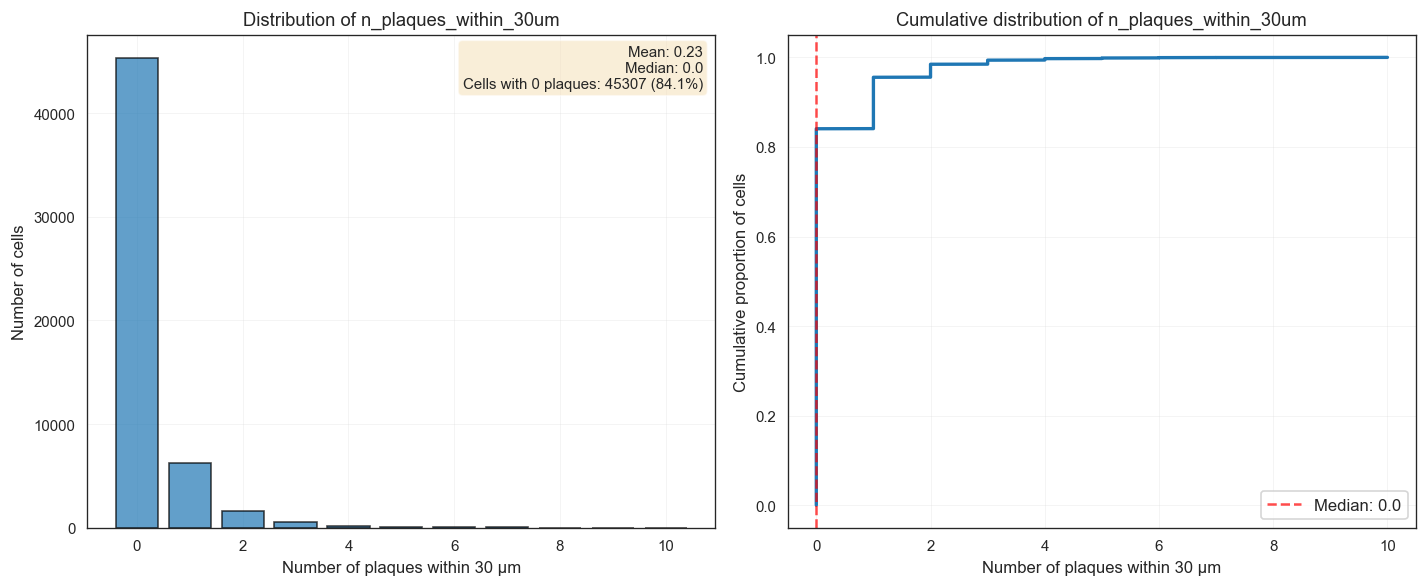


 Multi-plaque proximity features added to combined_df_normalized
 New columns: n_plaques_within_30um, mean_dist_to_plaques_within_30um


In [164]:
# Create diagnostic plot to evaluate if the threshold is informative
# This helps determine if 30 µm (or chosen threshold) is appropriate
plot_plaque_proximity_distribution(
    cells_df=combined_df_normalized_with_proximity,
    dist_threshold=dist_threshold,
    figsize=(12, 5),
)

# Update the main dataframe
combined_df_normalized_full = combined_df_normalized_with_proximity.copy()

print("\n Multi-plaque proximity features added to combined_df_normalized")
print(f" New columns: {proximity_col}, mean_dist_to_plaques_within_{dist_threshold:.0f}um")

### Neighborhood PIG Expression Features


To capture **cell-cell context** and spatial signaling patterns, we compute neighborhood mean expression features for Plaque-Induced Genes (PIGs). For each cell, we summarize the expression of PIG genes in its nearby cells, providing a quantitative measure of the local transcriptional environment that can be used as features in predictive models.


#### Algorithm: k-Nearest Neighbors Aggregation

For each cell \(i\) with coordinates \((x_i, y_i)\):

1. **Query neighbors**: Find the \(k+1\) nearest neighbors using KDTree (we query \(k+1\) to account for the cell itself)
2. **Exclude self**: Remove the first result (the cell itself, with distance ≈ 0)
3. **Aggregate expression**: For each PIG gene \(g\), compute the mean expression among the \(k\) neighbors

#### Mathematical Formulation

Let:
- \(N\) = total number of cells
- \(k\) = number of nearest neighbors (default: 100)
- \(\mathcal{P}\) = set of PIG genes (e.g., {Gfap, Apoe, Cst3, ...})
- \(x_{ig}\) = expression of gene \(g\) in cell \(i\)
- \(\mathcal{N}_i^{(k)}\) = set of \(k\) nearest neighbors of cell \(i\) (excluding cell \(i\) itself)

For each cell \(i\) and each PIG gene \(g \in \mathcal{P}\), we compute:

\[
\bar{x}_{ig}^{(neigh)} = \frac{1}{|\mathcal{N}_i^{(k)}|} \sum_{j \in \mathcal{N}_i^{(k)}} x_{jg}
\]

**Distance metric**: Euclidean distance in 2D space:
\[
d(i, j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}
\]

For each PIG gene \(g\), the function adds a column:
- **`neigh_mean_{gene}`**: Mean expression of gene \(g\) among the \(k\) nearest neighbors


- **k=100 neighbors**: 
   - Balances local context (not too small) with computational efficiency (not too large)
   - Captures neighborhood effects at a scale relevant to cell-cell communication (~10-50 µm radius, depending on cell density)

This should raise explanatory power (ΔR²) and reduce heteroscedasticity in the predictive models.



In [165]:
# Reload the module to ensure we have the latest version
import importlib
import src.scripts.analysis.spatial_features
importlib.reload(src.scripts.analysis.spatial_features)

# Import the function
from src.scripts.analysis.spatial_features import compute_pig_neighborhood_means
# Compute neighborhood PIG expression means with k=100 neighbors
logger.info("="*80)
logger.info("Computing neighborhood PIG expression means (k=100 neighbors)...")
logger.info("="*80)

combined_df_normalized_full = compute_pig_neighborhood_means(
    cells_df=combined_df_normalized_full2,
    pig_genes=PIG_GENES,
    k_neighbors=100
)

# Display summary of added columns
neigh_cols = [col for col in combined_df_normalized_full.columns if col.startswith("neigh_mean_")]
logger.info(f"\n✅ Added {len(neigh_cols)} neighborhood mean columns:")
for col in neigh_cols:
    logger.info(f"   - {col}")



Computing neighborhood PIG expression means (k=100 neighbors)...
Computing neighborhood PIG expression means for 53895 cells using k=100 neighbors and 16 PIG genes
✅ Computed neighborhood PIG expression means. Mean valid values per gene: 53895/53895 (100.0%)

✅ Added 16 neighborhood mean columns:
   - neigh_mean_Hexb
   - neigh_mean_Cst3
   - neigh_mean_Cd63
   - neigh_mean_C4b
   - neigh_mean_Ctsd
   - neigh_mean_B2m
   - neigh_mean_H2-K1
   - neigh_mean_Apoe
   - neigh_mean_Gfap
   - neigh_mean_Nrep
   - neigh_mean_Serpina3n
   - neigh_mean_Cd74
   - neigh_mean_Cxcl10
   - neigh_mean_Vim
   - neigh_mean_S100a6
   - neigh_mean_Ifit3


In [167]:
# Display sample statistics
if neigh_cols:
    print("\n" + "="*80)
    print("Neighborhood PIG Expression Summary Statistics")
    print("="*80)
    print(combined_df_normalized_full[neigh_cols].describe())
    print("\n" + "="*80)
    print(f"DataFrame shape after adding neighborhood features: {combined_df_normalized_full.shape}")
    print("="*80)
    
    # Show a few example rows
    print("\nSample of neighborhood mean values (first 5 cells):")
    print(combined_df_normalized_full[["cell_id"] + neigh_cols[:5]].head())


Neighborhood PIG Expression Summary Statistics
       neigh_mean_Hexb  neigh_mean_Cst3  neigh_mean_Cd63  neigh_mean_C4b  \
count     53895.000000     53895.000000     53895.000000    53895.000000   
mean          0.431039         2.543985         0.611468        0.520888   
std           0.146253         0.398129         0.205907        0.274853   
min           0.073369         1.086784         0.063561        0.006931   
25%           0.325429         2.352897         0.475530        0.311238   
50%           0.419185         2.602919         0.588552        0.469337   
75%           0.520821         2.806646         0.722982        0.672579   
max           1.133306         3.664870         2.044300        1.493569   

       neigh_mean_Ctsd  neigh_mean_B2m  neigh_mean_H2-K1  neigh_mean_Apoe  \
count     53895.000000    53895.000000      53895.000000     53895.000000   
mean          1.149988        0.733695          0.344109         1.809035   
std           0.292218        0.2593

 ### Ranking Neighbor PIGs by Correlation


After computing neighborhood mean expression features for PIG genes, we need to identify which neighbor PIG features are most informative for predicting each target PIG gene's expression. The `rank_neighbor_pigs_by_correlation` function computes correlations between each target PIG gene's expression and the neighborhood means of all other PIG genes, then ranks them by absolute correlation strength.


For each target gene \(g\) and neighbor gene \(h \neq g\):

**Pearson correlation** (linear relationship):
\[
r_{gh}^{(Pearson)} = \frac{\text{Cov}(\mathbf{y}_g, \mathbf{x}_h^{(neigh)})}{\sigma_{\mathbf{y}_g} \cdot \sigma_{\mathbf{x}_h^{(neigh)}}}
\]

**Spearman correlation** (monotonic relationship):
\[
\rho_{gh}^{(Spearman)} = \text{corr}(\text{rank}(\mathbf{y}_g), \text{rank}(\mathbf{x}_h^{(neigh)}))
\]

**Ranking**:
\[
\text{Rank}_g = \text{sort}\left(\left\{|r_{gh}| : h \in \mathcal{P}, h \neq g\right\}\right) \text{ (descending)}
\]


**High correlation** (\(|r| > 0.5\)) suggests:
- **Coordinated spatial expression**: The target gene and neighbor gene show similar spatial patterns
- **Potential co-regulation**: Genes may be responding to the same spatial signals
- **Spatial co-localization**: Cells expressing high levels of the target gene tend to be near cells expressing high levels of the neighbor gene

**Low correlation** (\(|r| < 0.2\)) suggests:
- **Independent spatial patterns**: The genes show different spatial distributions
- **Different regulatory mechanisms**: Genes may be responding to different spatial cues


In [ ]:
# Reload the module to ensure we have the latest version
import importlib
import src.scripts.analysis.regression_analysis
importlib.reload(src.scripts.analysis.regression_analysis)

from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    rank_neighbor_pigs_by_correlation,  
)
rankings = rank_neighbor_pigs_by_correlation(
    cells_df=combined_df_normalized_full,
    pig_genes=PIG_GENES,
    use_spearman=False  # or True for Spearman
)

# Access rankings for a specific gene
for neighbor_col, abs_corr in rankings['Gfap']:
    print(f"{neighbor_col}: {abs_corr:.4f}")

Ranked neighbor PIGs by correlation for 16 target genes (using Pearson correlation).
neigh_mean_C4b: 0.4726
neigh_mean_S100a6: 0.4656
neigh_mean_Vim: 0.4506
neigh_mean_Serpina3n: 0.3160
neigh_mean_Cd74: 0.3038
neigh_mean_Hexb: 0.2881
neigh_mean_B2m: 0.2483
neigh_mean_Cxcl10: 0.2213
neigh_mean_Cst3: 0.1743
neigh_mean_Ctsd: 0.1376
neigh_mean_H2-K1: 0.1301
neigh_mean_Cd63: 0.1275
neigh_mean_Nrep: 0.0994
neigh_mean_Ifit3: 0.0728
neigh_mean_Apoe: 0.0674


In [169]:
# Rank neighbor PIGs by correlation
logger.info("="*80)
logger.info("Ranking neighbor PIGs by correlation...")
logger.info("="*80)

# Compute rankings using Pearson correlation (default)
rankings_pearson = rank_neighbor_pigs_by_correlation(
    cells_df=combined_df_normalized_full,
    pig_genes=PIG_GENES,
    use_spearman=False
)

# Uncomment to compute using Spearman correlation
# rankings_spearman = rank_neighbor_pigs_by_correlation(
#    cells_df=combined_df_normalized_full,
#    pig_genes=PIG_GENES,
#    use_spearman=True
#)

# Display results for each target gene
print("\n" + "="*80)
print("Neighbor PIG Rankings by Correlation (Pearson)")
print("="*80)

for target_gene in sorted(rankings_pearson.keys()):
    print(f"\n Target gene: {target_gene}")
    print(f"   Top neighbor PIG features (by |correlation|):")
    for i, (neighbor_col, abs_corr) in enumerate(rankings_pearson[target_gene][:5], 1):
        # Extract gene name from column name (neigh_mean_GeneName -> GeneName)
        neighbor_gene = neighbor_col.replace("neigh_mean_", "")
        print(f"   {i}. {neighbor_gene:15s} (|r| = {abs_corr:.4f})")
    if len(rankings_pearson[target_gene]) > 5:
        print(f"   ... and {len(rankings_pearson[target_gene]) - 5} more")

# print("\n" + "="*80)
# print("Neighbor PIG Rankings by Correlation (Spearman)")
# print("="*80)
# 
# for target_gene in sorted(rankings_spearman.keys()):
#     print(f"\n📊 Target gene: {target_gene}")
#     print(f"   Top neighbor PIG features (by |correlation|):")
#     for i, (neighbor_col, abs_corr) in enumerate(rankings_spearman[target_gene][:5], 1):
#         neighbor_gene = neighbor_col.replace("neigh_mean_", "")
#         print(f"   {i}. {neighbor_gene:15s} (|ρ| = {abs_corr:.4f})")
#     if len(rankings_spearman[target_gene]) > 5:
#         print(f"   ... and {len(rankings_spearman[target_gene]) - 5} more")


Ranking neighbor PIGs by correlation...
Ranked neighbor PIGs by correlation for 16 target genes (using Pearson correlation).

Neighbor PIG Rankings by Correlation (Pearson)

 Target gene: Apoe
   Top neighbor PIG features (by |correlation|):
   1. Cd63            (|r| = 0.3079)
   2. Cst3            (|r| = 0.2852)
   3. B2m             (|r| = 0.2366)
   4. H2-K1           (|r| = 0.2128)
   5. Ctsd            (|r| = 0.2000)
   ... and 10 more

 Target gene: B2m
   Top neighbor PIG features (by |correlation|):
   1. H2-K1           (|r| = 0.3436)
   2. Ctsd            (|r| = 0.2794)
   3. Cd63            (|r| = 0.2737)
   4. Hexb            (|r| = 0.2631)
   5. Cst3            (|r| = 0.2553)
   ... and 10 more

 Target gene: C4b
   Top neighbor PIG features (by |correlation|):
   1. Gfap            (|r| = 0.3338)
   2. Vim             (|r| = 0.3030)
   3. S100a6          (|r| = 0.2735)
   4. Serpina3n       (|r| = 0.1926)
   5. Nrep            (|r| = 0.1629)
   ... and 10 more

 Target g

In [170]:
# Create a summary DataFrame for easier analysis
summary_rows = []
for target_gene in rankings_pearson.keys():
    for neighbor_col, abs_corr in rankings_pearson[target_gene]:
        neighbor_gene = neighbor_col.replace("neigh_mean_", "")
        summary_rows.append({
            "target_gene": target_gene,
            "neighbor_gene": neighbor_gene,
            "neighbor_col": neighbor_col,
            "abs_corr_pearson": abs_corr,
        })

# Add Spearman correlations
# for target_gene in rankings_spearman.keys():
#     for neighbor_col, abs_corr in rankings_spearman[target_gene]:
#         neighbor_gene = neighbor_col.replace("neigh_mean_", "")
#         # Find matching row and add Spearman correlation
#         for row in summary_rows:
#             if row["target_gene"] == target_gene and row["neighbor_gene"] == neighbor_gene:
#                 row["abs_corr_spearman"] = abs_corr
#                 break

neighbor_pig_rankings_df = pd.DataFrame(summary_rows)

# Display summary statistics
print("\n" + "="*80)
print("Summary Statistics")
print("="*80)
print(f"Total target genes analyzed: {len(rankings_pearson)}")
print(f"Total neighbor-gene pairs: {len(neighbor_pig_rankings_df)}")
print(f"\nTop 10 most informative neighbor features (Pearson):")
top_pearson = neighbor_pig_rankings_df.nlargest(10, "abs_corr_pearson")[
    ["target_gene", "neighbor_gene", "abs_corr_pearson"]
]
print(top_pearson.to_string(index=False))

# print(f"\nTop 10 most informative neighbor features (Spearman):")
# top_spearman = neighbor_pig_rankings_df.nlargest(10, "abs_corr_spearman")[
#     ["target_gene", "neighbor_gene", "abs_corr_spearman"]
# ]
# print(top_spearman.to_string(index=False))

logger.info("✅ Completed ranking neighbor PIGs by correlation")


Summary Statistics
Total target genes analyzed: 16
Total neighbor-gene pairs: 240

Top 10 most informative neighbor features (Pearson):
target_gene neighbor_gene  abs_corr_pearson
       Gfap           C4b          0.472588
       Gfap        S100a6          0.465570
       Gfap           Vim          0.450643
        Vim        S100a6          0.397924
       Cst3          Ctsd          0.355705
       Cst3          Hexb          0.351984
       Cst3          Apoe          0.347211
        B2m         H2-K1          0.343584
        C4b          Gfap          0.333846
        Vim          Gfap          0.324580
✅ Completed ranking neighbor PIGs by correlation



### Nested Regression Models for PIG Expression


This module implements a **nested regression modeling framework** to systematically assess how different spatial feature groups contribute to predicting Plaque-Induced Gene (PIG) expression. For each PIG gene, we fit a series of nested linear models that incrementally add feature groups, allowing us to quantify the contribution of each group using statistical tests.

The nested regression analysis fits four levels of models for each PIG gene:

1. **Model 0 (Baseline)**: `expr_g ~ distance_to_plaque`
   - Tests whether distance alone explains expression which is already done in point before 

2. **Model 1 (+ Plaque Geometry)**: `expr_g ~ distance + plaque_geometry`
   - Adds: `nearest_plaque_area`, `nearest_plaque_perimeter`, `nearest_plaque_major_axis`, `nearest_plaque_minor_axis`, `nearest_plaque_orientation`
   - Tests: Does plaque shape/size matter beyond distance?

3. **Model 2 (+ Multi-Plaque Proximity)**: `expr_g ~ distance + geometry + multi_plaque`
   - Adds: `n_plaques_within_Rum`, `mean_dist_to_plaques_within_Rum`
   - Tests: Does plaque density in the local neighborhood matter?

4. **Model 3(k) (+ Neighborhood PIGs)**: `expr_g ~ distance + geometry + multi_plaque + top_k_neighbor_PIGs`
   - Adds: Top-k neighbor PIG mean expression features (ranked by correlation)
   - Tests: Does cell-cell signaling (neighbor PIG expression) improve prediction?
   - Varies k ∈ {1, 2, 4, 8, 15} to identify optimal number of neighbor features

#### Key Features

- **Statistical significance testing**: Uses nested F-tests to assess whether adding features significantly improves fit
- **Gene-specific neighbor ranking**: Each PIG gene uses its most informative neighbor features (ranked by correlation)
- **Saturation analysis**: Varying k identifies how many neighbor features are optimal
- **Result separation**: Automatically separates results into model summaries and nested comparisons for clean interpretation



### Combined Results (`nested_regression_results`)

The raw output from `regress_expression_with_spatial_features()` contains one row per gene-model combination:

| Column | Description |
|--------|-------------|
| `gene` | PIG gene name |
| `model` | Model identifier ("0", "1", "2", or "3_k") |
| `r_squared` | R² value (proportion of variance explained) |
| `adj_r_squared` | Adjusted R² (penalized for model complexity) |
| `n_obs` | Number of observations used |
| `n_params` | Number of parameters (including intercept) |
| `f_test_pval` | P-value from nested F-test (NaN for Model 0) |
| `f_test_fstat` | F-statistic from nested F-test (NaN for Model 0) |





In [171]:
import importlib
import src.scripts.analysis.regression_analysis
importlib.reload(src.scripts.analysis.regression_analysis)
# Update this line in Cell 2:
from src.scripts.analysis.regression_analysis import (
     compute_gene_spatial_stats,
     rank_neighbor_pigs_by_correlation,
     regress_expression_with_spatial_features,
     separate_nested_regression_results  
 )

In [172]:
# Nested Regression Analysis with Spatial Features
logger.info("="*80)
logger.info("Fitting nested regression models per PIG gene...")
logger.info("="*80)

# Determine which rankings to use (prefer rankings_pearson if available)
# The function will compute rankings automatically if neighbor_rankings=None
try:
    neighbor_rankings_to_use = rankings_pearson
    logger.info("Using pre-computed rankings_pearson")
except NameError:
    try:
        neighbor_rankings_to_use = rankings_spearman
        logger.info("Using pre-computed rankings_spearman")
    except NameError:
        neighbor_rankings_to_use = None
        logger.info("No pre-computed rankings found. Will compute automatically.")

# Run nested regression analysis
# This will fit models 0, 1, 2, and 3(k) for each PIG gene
nested_regression_results = regress_expression_with_spatial_features(
    cells_df=combined_df_normalized_full,
    pig_genes=PIG_GENES,
    neighbor_rankings=neighbor_rankings_to_use,  # Use pre-computed rankings if available
    distance_col="distance_to_plaque",
    k_values=[1, 2, 4, 8, 15]  # Top-k neighbor PIG features to include
)

Fitting nested regression models per PIG gene...
Using pre-computed rankings_pearson
Fitting nested regression models for 16 PIG genes. Available features: 5 geometry, 2 multi-plaque proximity
✅ Completed nested regression analysis. Fitted models for 16 genes, total 128 model fits.


In [175]:
# Display results by model type
print("\n" + "="*80)
print("Results by Model Type")
print("="*80)

for model_type in sorted(nested_regression_results['model'].unique()):
    model_data = nested_regression_results[nested_regression_results['model'] == model_type]
    print(f"\n Model {model_type}:")
    print(f"   Number of genes: {len(model_data)}")
    print(f"   Mean R²: {model_data['r_squared'].mean():.4f}")
    print(f"   Mean Adjusted R²: {model_data['adj_r_squared'].mean():.4f}")
    if model_type != "0":  # Model 0 has no F-test
        print(f"   Mean F-statistic: {model_data['f_test_fstat'].mean():.4f}")
        print(f"   Significant improvements (p < 0.05): {(model_data['f_test_pval'] < 0.05).sum()}/{len(model_data)}")
        print(f"   Significant improvements (p < 0.01): {(model_data['f_test_pval'] < 0.01).sum()}/{len(model_data)}")


Results by Model Type

 Model 0:
   Number of genes: 16
   Mean R²: 0.0143
   Mean Adjusted R²: 0.0142

 Model 1:
   Number of genes: 16
   Mean R²: 0.0169
   Mean Adjusted R²: 0.0168
   Mean F-statistic: 29.7205
   Significant improvements (p < 0.05): 15/16
   Significant improvements (p < 0.01): 15/16

 Model 2:
   Number of genes: 16
   Mean R²: 0.0263
   Mean Adjusted R²: 0.0254
   Mean F-statistic: 29.9138
   Significant improvements (p < 0.05): 16/16
   Significant improvements (p < 0.01): 14/16

 Model 3_1:
   Number of genes: 16
   Mean R²: 0.0930
   Mean Adjusted R²: 0.0920
   Mean F-statistic: 665.1038
   Significant improvements (p < 0.05): 16/16
   Significant improvements (p < 0.01): 16/16

 Model 3_15:
   Number of genes: 16
   Mean R²: 0.1341
   Mean Adjusted R²: 0.1317
   Mean F-statistic: 75.4696
   Significant improvements (p < 0.05): 16/16
   Significant improvements (p < 0.01): 16/16

 Model 3_2:
   Number of genes: 16
   Mean R²: 0.1033
   Mean Adjusted R²: 0.1023

In [191]:
# Display top improvements by F-test p-value
print("\n" + "="*80)
print("Top Model Improvements (by F-test p-value)")
print("="*80)

# Filter to models with F-tests (exclude Model 0)
models_with_tests = nested_regression_results[nested_regression_results['f_test_pval'].notna()].copy()
if not models_with_tests.empty:
    # Sort by F-test p-value (ascending = most significant)
    top_improvements = models_with_tests.nsmallest(20, 'f_test_pval')[
        ['gene', 'model', 'r_squared', 'adj_r_squared', 'f_test_pval', 'f_test_fstat']
    ]
    print(top_improvements.to_string(index=False))
else:
    print("No F-test results available (only Model 0 was fitted)")



Top Model Improvements (by F-test p-value)
  gene model  r_squared  adj_r_squared   f_test_pval  f_test_fstat
  Cst3  3_15   0.194758       0.192596  0.000000e+00    119.305625
  Gfap   3_1   0.223781       0.222967  0.000000e+00   2008.766101
  Gfap   3_2   0.262462       0.261602  0.000000e+00   1281.849910
  Gfap   3_4   0.268829       0.267806  0.000000e+00    665.022906
  Gfap   3_8   0.299677       0.298369  0.000000e+00    394.187334
  Gfap  3_15   0.333510       0.331720  0.000000e+00    249.707389
   Vim   3_2   0.231146       0.230250  0.000000e+00    892.113088
   Vim   3_4   0.236335       0.235267  0.000000e+00    463.549657
   Vim   3_8   0.246762       0.245356  0.000000e+00    249.704292
   Vim  3_15   0.251111       0.249100  0.000000e+00    137.155302
   Vim   3_1   0.215988       0.215165 4.812372e-318   1584.082867
  Cst3   3_8   0.175971       0.174433 2.609263e-303    194.350935
  Cst3   3_4   0.151918       0.150731 8.137051e-255    317.052613
S100a6  3_15   0.1

### Separated Results

#### (A) Model Summaries (`model_summaries`)

Each row describes one fitted model:

| Column | Description |
|--------|-------------|
| `gene` | PIG gene name |
| `model` | Model identifier |
| `features_used` | Description of features in the model |
| `r_squared` | R² value |
| `adj_r_squared` | Adjusted R² value |
| `n_obs` | Number of observations |
| `n_params` | Number of parameters |

**Use case**: Understanding individual model performance and what features each model uses.


In [ ]:
from src.scripts.analysis.regression_analysis import separate_nested_regression_results

# Separate the results into two groups
model_summaries, nested_comparisons = separate_nested_regression_results(
    nested_regression_results
)

# Now display the separated results
print("\n" + "="*80)
print("(A) Model Summaries")
print("="*80)
print("\nEach row describes a fitted model with its features and performance:")
print(model_summaries.head(5).to_string(index=False))
if len(model_summaries) > 5:
    print(f"\n... and {len(model_summaries) - 5} more model summaries")

✅ Separated results: 128 model summaries, 112 nested comparisons

(A) Model Summaries

Each row describes a fitted model with its features and performance:
gene model                                                                                                                                                       features_used  r_squared  adj_r_squared  n_obs  n_params
Hexb     0                                                                                                                                                  distance_to_plaque   0.013844       0.013826  53895       2.0
Hexb     1                                                                         distance_to_plaque + plaque_geometry (area, perimeter, major_axis, minor_axis, orientation)   0.014184       0.014075  53895       7.0
Hexb     2                                                       distance_to_plaque + plaque_geometry + multi_plaque_proximity (n_plaques_within_radius, mean_dist_to_plaques)   0.065682     

#### (B) Nested Comparisons (`nested_comparisons`)

Each row describes an improvement when adding a feature block:

| Column | Description |
|--------|-------------|
| `gene` | PIG gene name |
| `comparison` | Comparison label (e.g., "M0→M1", "M1→M2", "M2→M3_1") |
| `model_from` | Source model identifier |
| `model_to` | Target model identifier |
| `delta_r_squared` | Improvement in R² (R²_to - R²_from) |
| `delta_adj_r_squared` | Improvement in adjusted R² |
| `f_test_pval` | P-value from nested F-test |
| `f_test_fstat` | F-statistic from nested F-test |

**Use case**: Identifying which feature additions are statistically significant and how much they improve prediction.

In [190]:
print("\n" + "="*80)
print("(B) Nested Comparisons")
print("="*80)
print("\nEach row describes an improvement when adding a feature block:")
print(nested_comparisons.head(5).to_string(index=False))
if len(nested_comparisons) > 5:
    print(f"\n... and {len(nested_comparisons) - 5} more comparisons")



(B) Nested Comparisons

Each row describes an improvement when adding a feature block:
gene comparison model_from model_to  delta_r_squared  delta_adj_r_squared   f_test_pval  f_test_fstat
Apoe      M0→M1          0        1         0.002461             0.002369  3.350351e-27     26.834812
Apoe      M1→M2          1        2        -0.002947            -0.003762  1.761704e-11     24.833765
Apoe    M2→M3_1          2      3_1         0.049875             0.049811  2.701418e-98    454.423448
Apoe M3_8→M3_15        3_8     3_15         0.009476             0.008757 4.533061e-169     58.697687
Apoe  M3_4→M3_8        3_4      3_8         0.010465             0.010055 1.857092e-156     97.823415

... and 107 more comparisons


In [197]:
# Summary of significant improvements
print("\n" + "="*80)
print("Significant Improvements (p < 0.05)")
print("="*80)
significant = nested_comparisons[nested_comparisons['f_test_pval'] < 0.05]
if not significant.empty:
    print(f"\nTotal significant improvements: {len(significant)}/{len(nested_comparisons)}")
    print("\nTop improvements by ΔR²:")
    top_improvements = significant.nlargest(5, 'delta_r_squared')[
        ['gene', 'comparison', 'delta_r_squared', 'delta_adj_r_squared', 'f_test_pval']
    ]
    print(top_improvements.to_string(index=False))
else:
    print("\nNo significant improvements found (all p ≥ 0.05)")
# The separated DataFrames are now available:
# - model_summaries: Model descriptions with features, R², adj R², n_obs
# - nested_comparisons: Model comparisons with ΔR², p-values, F-stats
# - nested_regression_results: Original combined results


Significant Improvements (p < 0.05)

Total significant improvements: 111/112

Top improvements by ΔR²:
  gene comparison  delta_r_squared  delta_adj_r_squared   f_test_pval
  Gfap    M2→M3_1         0.181772             0.181851  0.000000e+00
   Vim    M2→M3_1         0.144782             0.144826 4.812372e-318
S100a6    M2→M3_1         0.108342             0.108340 1.769811e-218
  Cst3    M2→M3_1         0.104679             0.104676 3.308699e-214
  Ctsd    M2→M3_1         0.089874             0.089857 1.076954e-187


### FDR Correction and Summary Tables for Nested Regression

After fitting nested regression models for PIG genes, we need to:
1. **Correct for multiple testing** to control false discovery rate (FDR)
2. **Create interpretable summary tables** to understand feature block importance and spatial gene relationships

Apply Benjamini-Hochberg FDR correction separately for each comparison type (M0→M1, M1→M2, M2→M3_k, etc.).
We correct within comparison types because different types test different hypotheses, but within each type we're testing the same hypothesis across genes.

#### Summary Tables

#### Table 1: Feature Block Importance

Shows which feature blocks are most important **across all PIG genes**:

| Metric | Description |
|--------|-------------|
| `mean_delta_r_squared` | Average improvement in R² when adding this feature block |
| `median_delta_r_squared` | Median improvement (more robust to outliers) |
| `n_significant` | Number of genes with significant improvement (FDR-corrected) |
| `n_tested` | Total number of genes tested |
| `pct_significant` | Percentage of genes showing significant improvement |


#### Table 2: Best Neighbor PIGs for Each Gene

Shows, for each target gene, which neighbor PIG features are most informative:

| Column | Description |
|--------|-------------|
| `gene` | Target PIG gene name |
| `best_k` | Optimal number of neighbor features |
| `best_model` | Model identifier (e.g., "3_4") |
| `delta_r_squared` | Improvement in R² from neighbor features |
| `is_significant` | Whether improvement is significant (FDR-corrected) |
| `top_k_neighbor_genes` | Which neighbor genes are in the top-k |


#### Understanding FDR Correction

- **Before correction**: Raw p-values from nested F-tests
- **After correction**: FDR-adjusted p-values that control false discovery rate
- **Interpretation**: Use `f_test_pval_adj < 0.05` to identify significant improvements



In [196]:
import importlib
import src.scripts.analysis.regression_analysis
importlib.reload(src.scripts.analysis.regression_analysis)
from src.scripts.analysis.regression_analysis import (
    apply_fdr_correction_to_comparisons,
    create_feature_block_importance_table,
    create_best_neighbor_pigs_table,
)

# Apply FDR correction to nested comparisons
# This corrects for multiple testing across genes within each comparison type
logger.info("="*80)
logger.info("Applying FDR correction for multiple testing...")
logger.info("="*80)

nested_comparisons_corrected = apply_fdr_correction_to_comparisons(
    nested_comparisons=nested_comparisons,
    alpha=0.05
)

# Update nested_comparisons to include corrected p-values
nested_comparisons = nested_comparisons_corrected

# Display comparison: before vs after correction
print("\n" + "="*80)
print("FDR Correction Summary")
print("="*80)
n_sig_before = (nested_comparisons['f_test_pval'] < 0.05).sum()
n_sig_after = (nested_comparisons['f_test_pval_adj'] < 0.05).sum()
print(f"\nSignificant improvements (p < 0.05):")
print(f"  Before FDR correction: {n_sig_before}/{len(nested_comparisons)}")
print(f"  After FDR correction:  {n_sig_after}/{len(nested_comparisons)}")
print(f"  Reduction: {n_sig_before - n_sig_after} comparisons no longer significant")


Applying FDR correction for multiple testing...
✅ Applied FDR correction. Significant before: 111, after: 111 (α = 0.05)

FDR Correction Summary

Significant improvements (p < 0.05):
  Before FDR correction: 111/112
  After FDR correction:  111/112
  Reduction: 0 comparisons no longer significant


In [ ]:
# ============================================================================
# Create summary tables
# ============================================================================

logger.info("="*80)
logger.info("Creating summary tables...")
logger.info("="*80)

# Table 1: Feature Block Importance Across All PIGs
print("\n" + "="*80)
print("Table 1: Feature Block Importance Across All PIGs")
print("="*80)
print("\nThis table shows the importance of each feature block across all genes:")
print("(Uses FDR-corrected p-values)")

feature_importance_table = create_feature_block_importance_table(
    nested_comparisons=nested_comparisons,
    alpha=0.05,
    use_fdr_corrected=True
)

if not feature_importance_table.empty:
    print("\n" + feature_importance_table.to_string(index=False))
    
    # Interpretation
    print("\n" + "="*80)
    print("Interpretation:")
    print("="*80)
    print("- mean_delta_r_squared: Average improvement in R² when adding this feature block")
    print("- median_delta_r_squared: Median improvement (more robust to outliers)")
    print("- n_significant: Number of genes with significant improvement (FDR-corrected p < 0.05)")
    print("- pct_significant: Percentage of genes showing significant improvement")
    print("\nKey insights:")
    
    # Find most important feature block
    if len(feature_importance_table) > 0:
        most_important = feature_importance_table.loc[
            feature_importance_table['mean_delta_r_squared'].idxmax()
        ]
        print(f"\n  • Largest mean improvement: {most_important['comparison']} "
              f"(ΔR² = {most_important['mean_delta_r_squared']:.4f})")
        
        most_common_sig = feature_importance_table.loc[
            feature_importance_table['pct_significant'].idxmax()
        ]
        print(f"  • Most consistently significant: {most_common_sig['comparison']} "
              f"({most_common_sig['pct_significant']:.1f}% of genes significant)")
else:
    print("\nNo feature importance data available.")



Creating summary tables...

Table 1: Feature Block Importance Across All PIGs

This table shows the importance of each feature block across all genes:
(Uses FDR-corrected p-values)
✅ Created feature block importance table with 7 comparison types

comparison  mean_delta_r_squared  median_delta_r_squared  n_significant  n_tested  pct_significant
     M0→M1              0.002674                0.002031             15        16            93.75
     M1→M2              0.009368                0.002979             16        16           100.00
   M2→M3_1              0.066678                0.047300             16        16           100.00
 M3_1→M3_2              0.010339                0.008753             16        16           100.00
 M3_2→M3_4              0.008950                0.005778             16        16           100.00
 M3_4→M3_8              0.010274                0.008636             16        16           100.00
M3_8→M3_15              0.011528                0.008435    



**Which feature block is most important?**
- Compare `mean_delta_r_squared` across comparison types
- Higher values → more variance explained on average

**Is the effect consistent across genes?**
- High `pct_significant` → feature block matters for most genes
- Low `pct_significant` → feature block is gene-specific

**How many neighbor features are optimal?**
- Compare M2→M3_1, M2→M3_2, M2→M3_4, M2→M3_8, M2→M3_15
- Find where `mean_delta_r_squared` plateaus → optimal k



In [204]:
# Table 2: Best Neighbor PIGs for Each Gene
print("\n" + "="*80)
print("Table 2: Best Neighbor PIGs for Each Gene")
print("="*80)
print("\nThis table shows, for each target gene, which neighbor PIG features are most informative:")
print("(Uses FDR-corrected p-values)")
# Get neighbor rankings (use the one that was used in regression)
try:
    rankings_for_table = neighbor_rankings_to_use
except NameError:
    try:
        rankings_for_table = rankings_pearson
    except NameError:
        try:
            rankings_for_table = rankings_spearman
        except NameError:
            rankings_for_table = None
            logger.warning("No neighbor rankings found. Table 2 will be incomplete.")

if rankings_for_table is not None:
    best_neighbors_table = create_best_neighbor_pigs_table(
        nested_comparisons=nested_comparisons,
        neighbor_rankings=rankings_for_table,
        alpha=0.05,
        use_fdr_corrected=True
    )
    
    if not best_neighbors_table.empty:
        print("\n" + best_neighbors_table.to_string(index=False))
        
        # Summary statistics
        print("\n" + "="*80)
        print("Summary Statistics:")
        print("="*80)
        print(f"  • Genes with significant neighbor PIG effects: "
              f"{best_neighbors_table['is_significant'].sum()}/{len(best_neighbors_table)}")
        print(f"  • Mean optimal k: {best_neighbors_table['best_k'].mean():.1f}")
        print(f"  • Median optimal k: {best_neighbors_table['best_k'].median():.0f}")
        print(f"  • Mean ΔR² from neighbor PIGs: {best_neighbors_table['delta_r_squared'].mean():.4f}")
        
        # Most informative neighbor genes (across all target genes)
        all_neighbor_genes = []
        for genes_str in best_neighbors_table['top_k_neighbor_genes']:
            if pd.notna(genes_str) and genes_str:
                all_neighbor_genes.extend([g.strip() for g in genes_str.split(',')])
        
        if all_neighbor_genes:
            from collections import Counter
            neighbor_counts = Counter(all_neighbor_genes)
            print(f"\n  • Most frequently informative neighbor genes:")
            for gene, count in neighbor_counts.most_common(5):
                print(f"    - {gene}: appears in top-k for {count} target genes")
    else:
        print("\nNo best neighbor data available.")
else:
    print("\n⚠️ Neighbor rankings not available. Cannot create Table 2.")
    print("   Run rank_neighbor_pigs_by_correlation() first to generate rankings.")




Table 2: Best Neighbor PIGs for Each Gene

This table shows, for each target gene, which neighbor PIG features are most informative:
(Uses FDR-corrected p-values)
✅ Created best neighbor PIGs table for 16 genes. 16 genes have significant improvements.

     gene  best_k best_model  delta_r_squared  delta_adj_r_squared   f_test_pval  is_significant top_k_neighbor_genes top_k_neighbor_cols
     Gfap       1        3_1         0.181772             0.181851  0.000000e+00            True                  C4b      neigh_mean_C4b
      Vim       1        3_1         0.144782             0.144826 3.849898e-317            True               S100a6   neigh_mean_S100a6
   S100a6       1        3_1         0.108342             0.108340 9.438991e-218            True                  Vim      neigh_mean_Vim
     Cst3       1        3_1         0.104679             0.104676 1.323479e-213            True                 Ctsd     neigh_mean_Ctsd
     Ctsd       1        3_1         0.089874           


**Which genes influence each other spatially?**
- Look at `top_k_neighbor_genes` for each target
- Reveals spatial co-expression networks

**How many neighbors are needed?**
- `best_k` shows optimal number per gene
- Consistent k across genes → universal signaling pattern
- Variable k → gene-specific signaling

**Which genes are most central?**
- Count how often each gene appears in `top_k_neighbor_genes`
- Frequent genes → key spatial regulators
